# BÀI THỰC HÀNH 3: MẠNG NEURAL HỒI QUY CHO BÀI TOÁN PHÂN LOẠI VĂN BẢN VÀ GÁN NHÃN CHUỖI

<b>Hướng dẫn nộp bài:</b> Các bạn commit và push code lên github, sử dụng file txt đặt tên theo cú pháp <MSSV>.txt chứa đường link dẫn đến github của bài thực hành và nộp file txt này tên courses.

Bộ dữ liệu sử dụng: [UIT-VSFC](https://drive.google.com/drive/folders/1rdcXNGt_3-QUvV8EtSvVsLMVeHmk6Yqk?usp=drive_link) và [PhoNERT](https://github.com/VinAIResearch/PhoNER_COVID19).

In [1]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Bài 1: Xây dựng mạng LSTM gồm 5 lớp với hidden size là 256 cho bài toán phân loại văn bản. Huấn luyện mô hình này trên bộ dữ liệu UIT-VSFC (Vietnamese Student Feedback Corpus) sử dụng Adam làm phương thức tối ưu tham số và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

In [3]:
# Tải toàn bộ thư mục từ Google Drive về máy
!gdown --folder https://drive.google.com/drive/folders/1rdcXNGt_3-QUvV8EtSvVsLMVeHmk6Yqk
!pip install underthesea

Retrieving folder contents
Processing file 1UWbzHFeUPu4AuofOEy0Fo0SFotVZHzUe UIT-VSFC-dev.json
Processing file 1g4imdabNbswIu91K6zKFGalkjDBBqaQq UIT-VSFC-test.json
Processing file 1eJdEStCQBf3GtbOIQfIR2iS-Wb3nlfJX UIT-VSFC-train.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1UWbzHFeUPu4AuofOEy0Fo0SFotVZHzUe
To: /content/UIT-VSFC/UIT-VSFC-dev.json
100% 274k/274k [00:00<00:00, 139MB/s]
Downloading...
From: https://drive.google.com/uc?id=1g4imdabNbswIu91K6zKFGalkjDBBqaQq
To: /content/UIT-VSFC/UIT-VSFC-test.json
100% 559k/559k [00:00<00:00, 150MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eJdEStCQBf3GtbOIQfIR2iS-Wb3nlfJX
To: /content/UIT-VSFC/UIT-VSFC-train.json
100% 2.02M/2.02M [00:00<00:00, 183MB/s]
Download completed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 118.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 k

## EDA Dataset

### 1. Kiểm tra cấu trúc bộ dữ liệu

In [ ]:
data_dir = "/content/UIT-VSFC/"

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_raw = load_json(os.path.join(data_dir, "UIT-VSFC-train.json"))
dev_raw   = load_json(os.path.join(data_dir, "UIT-VSFC-dev.json"))
test_raw  = load_json(os.path.join(data_dir, "UIT-VSFC-test.json"))

In [ ]:
# Kiểm tra các cột có trong dataset (ví dụ: sentence, label).

print(train_raw[0].keys())
print(train_raw[0])

dict_keys(['sentence', 'sentiment', 'topic'])
{'sentence': 'slide giáo trình đầy đủ .', 'sentiment': 'positive', 'topic': 'training_program'}


In [6]:
# Kiểm tra số lượng mẫu train/valid/test.
print(len(train_raw), len(dev_raw), len(test_raw))

11426 1583 3166


In [7]:
# Lấy 10 mẫu đầu tiên để xem dữ liệu thực trông như thế nào.
train_raw[:10]

[{'sentence': 'slide giáo trình đầy đủ .',
  'sentiment': 'positive',
  'topic': 'training_program'},
 {'sentence': 'nhiệt tình giảng dạy , gần gũi với sinh viên .',
  'sentiment': 'positive',
  'topic': 'lecturer'},
 {'sentence': 'đi học đầy đủ full điểm chuyên cần .',
  'sentiment': 'negative',
  'topic': 'training_program'},
 {'sentence': 'chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .',
  'sentiment': 'negative',
  'topic': 'lecturer'},
 {'sentence': 'thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .',
  'sentiment': 'positive',
  'topic': 'lecturer'},
 {'sentence': 'giảng viên đảm bảo thời gian lên lớp , tích cực trả lời câu hỏi của sinh viên , thường xuyên đặt câu hỏi cho sinh viên .',
  'sentiment': 'positive',
  'topic': 'lecturer'},
 {'sentence': 'em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp .',
  'sentiment': 'neutral',
  'topic': 'others'},
 {'sentence': 'thời lượng học quá dài , không đảm bảo tiếp thu hiệu quả .',
  'se

### 2. Phân tích phân bố nhãn (Label Distribution)

In [8]:
# Thống kê tần suất mỗi nhãn (Positive / Negative / Neutral).

sentiments = [ex['sentiment'] for ex in train_raw]

sentiment_counts = Counter(sentiments)

print("Sentiment Distribution (train):")
for label, count in sentiment_counts.items():
    print(f"{label}: {count}")

Sentiment Distribution (train):
positive: 5643
negative: 5325
neutral: 458


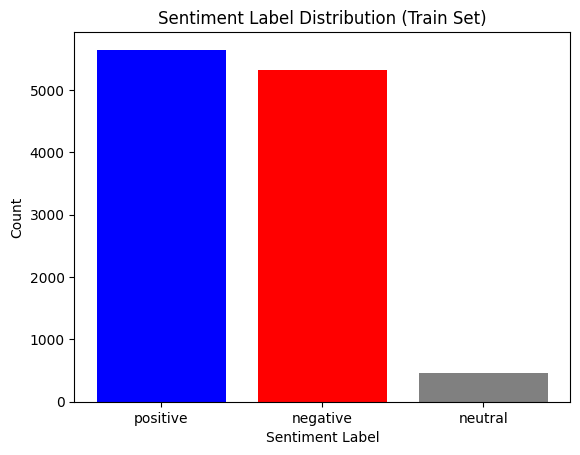

In [9]:
# Vẽ biểu đồ (bar chart) phân bố nhãn.
labels = list(sentiment_counts.keys())
counts = list(sentiment_counts.values())

plt.bar(labels, counts, color=['blue', 'red', 'gray'])
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.title('Sentiment Label Distribution (Train Set)')
plt.show()


**Trả lời câu hỏi**: Bộ dữ liệu có bị mất cân bằng nhãn không?

* Bộ dữ liệu **CÓ** bị mất cân bằng nhãn. Trong khi 2 nhãn **positive** và **negative** đều > 5k mẫu thì **neutral** lại chỉ có khoảng 500 mẫu. Điều này có thể khiến mô hình bias nhiều chỉ dự đoán đc 2 lớp lớn, bỏ qua hoặc dự đoán sau nhãn neutral.

### 3. Phân tích độ dài câu

In [10]:
# Tính số token/word trong từng câu (tách bởi khoảng trắng, loại bỏ dư thừa đầu/cuối).
sentences = [ex['sentence'] for ex in train_raw]

token_len = [len(sentence.strip().split()) for sentence in sentences]

print(token_len[:10])

[6, 11, 9, 18, 15, 28, 18, 14, 30, 16]


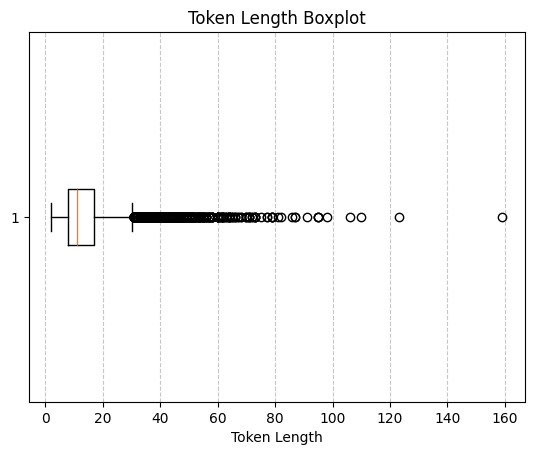

In [11]:
# Vẽ boxplot độ dài câu.
plt.boxplot(token_len, vert=False)
plt.xlabel('Token Length')
plt.title('Token Length Boxplot')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


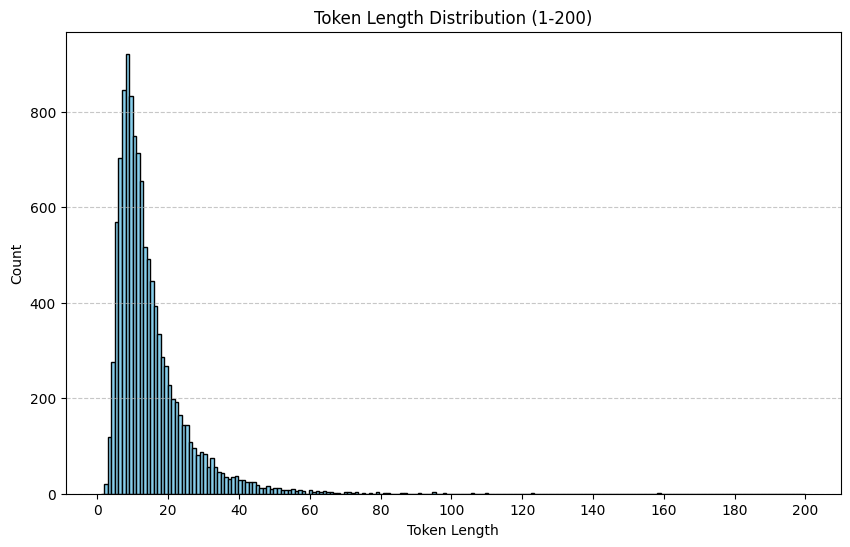

In [12]:
# Vẽ histogram độ dài câu.

plt.figure(figsize=(10,6))
plt.hist(token_len, bins=200, range=(1, 200), color='skyblue', edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Count')
plt.title('Token Length Distribution (1-200)')
plt.xticks(range(0, 201, 20))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Tìm: Max sequence length hợp lý khi padding (ví dụ: 50, 100, 200).

-> Max sequence length hợp lý sẽ là **60**: 

* Vẫn giữ đc hầu hết các dữ liệu.

* Tốn ít chi phí huấn luyện hơn.

### 4. Thống kê từ vựng

In [13]:
# Đếm số lượng từ vựng (unique tokens).

unique_tokens = set()
for sentence in sentences:
    tokens = sentence.lower().strip().split()
    unique_tokens.update(tokens)
print("Số lượng từ vựng (unique tokens):", len(unique_tokens))

Số lượng từ vựng (unique tokens): 2514


In [14]:
# Top 20 từ xuất hiện nhiều nhất.

all_tokens = []
for sentence in sentences:
    tokens = sentence.lower().strip().split()
    all_tokens.extend(tokens)

counter = Counter(all_tokens)
top_20 = counter.most_common(20)
print("Top 20 từ xuất hiện nhiều nhất:")
for word, freq in top_20:
    print(f"{word}: {freq}")

Top 20 từ xuất hiện nhiều nhất:
.: 11009
,: 6827
viên: 4803
giảng: 3711
dạy: 3156
thầy: 3095
sinh: 3082
học: 2940
bài: 2336
tình: 2266
không: 2177
và: 2068
có: 2031
rất: 1961
nhiệt: 1931
cho: 1735
hiểu: 1730
nhiều: 1622
tập: 1454
dễ: 1438


**Trả lời câu hỏi: Có cần làm preprocessing không? (lowercase, remove punctuation, fix unicode…)**

* Đối với các mô hình **transformer** thì không cần 

* Đối với **LSTM** thì cần phải làm preprocessing: Do mô hình rất nhạy cảm với các từ hiếm, noise, dấu câu không cần thiết, token dài bất thường.

### 5. Tiền xử lý dữ liệu

**Quy trình xử lý dữ liệu**

1. `normalize_unicode()`: chuẩn hóa toàn bộ văn bản về dạng Unicode NFC để nhất quán dấu tiếng Việt.
2. `remove_emoji()`: loại bỏ emoji/ký tự biểu tượng nhằm tránh thêm token nhiễu.
3. `remove_urls_emails_html_markdown()`: gỡ liên kết, email, thẻ HTML và định dạng markdown khỏi câu.
4. `text.lower()`: chuyển toàn bộ chuỗi về chữ thường để giảm kích thước từ vựng.
5. `word_tokenize(text, format="text")`: tách từ tiếng Việt bằng thư viện `underthesea` để giữ được cụm từ có nghĩa.
6. `remove_special_chars()`: xóa mã code giáo viên như là `wzjwz`, xóa dấu câu, số, ký tự lặp/nhân đôi và chuẩn hóa khoảng trắng trước khi đưa vào mô hình.

In [15]:
import unicodedata
import re
from underthesea import word_tokenize

def normalize_unicode(text):
    # Chuẩn hóa unicode về dạng NFC
    return unicodedata.normalize('NFC', text)

def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub(r'', text)

def remove_urls_emails_html_markdown(text):
    # Xoá URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # Xoá email
    text = re.sub(r"\S+@\S+", "", text)
    # Xoá HTML tag
    text = re.sub(r"<.*?>", "", text)
    # Xoá markdown, link ảnh [text](link)
    text = re.sub(r"\[.*?\]\(.*?\)", "", text)
    return text

def remove_special_chars(text):
    # Xoá dấu câu (trừ _), số, ký tự kéo dài, khoảng trắng thừa
    re.sub(r"\bwzjwz[a-zA-Z0-9]{1,6}\b", "", text)
    text = re.sub(r"[^\w\s_]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1", text)
    text = re.sub(r'\b(\w+)( \1\b)+', r'\1', text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text):
    text = normalize_unicode(text)
    text = remove_emoji(text)
    text = remove_urls_emails_html_markdown(text)
    text = text.lower()
    text = word_tokenize(text, format="text") 
    text = remove_special_chars(text)
    return text

processed_sentences = [preprocess_text(sentence) for sentence in sentences]

In [16]:
# Minh hoạ: Trước tiền xử lý và sau tiền xử lý
example_sentence = sentences[0]

print("Before:", example_sentence)
print("After :", preprocess_text(example_sentence))


Before: slide giáo trình đầy đủ .
After : slide giáo_trình đầy_đủ


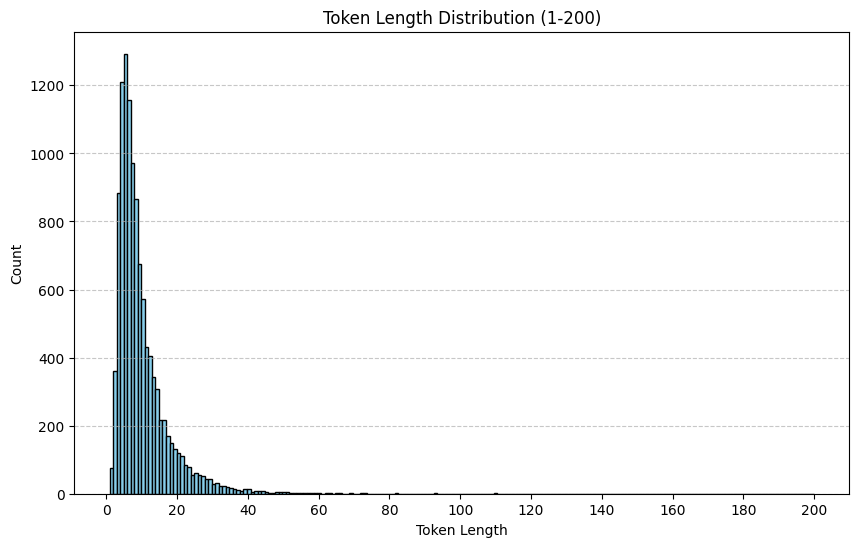

In [ ]:
processed_token_len = [len(processed_sentence.strip().split())for processed_sentence in processed_sentences]

# Vẽ histogram độ dài câu.
plt.figure(figsize=(10,6))
plt.hist(processed_token_len, bins=200, range=(1, 200), color='skyblue', edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Count')
plt.title('Token Length Distribution (1-200)')
plt.xticks(range(0, 201, 20))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

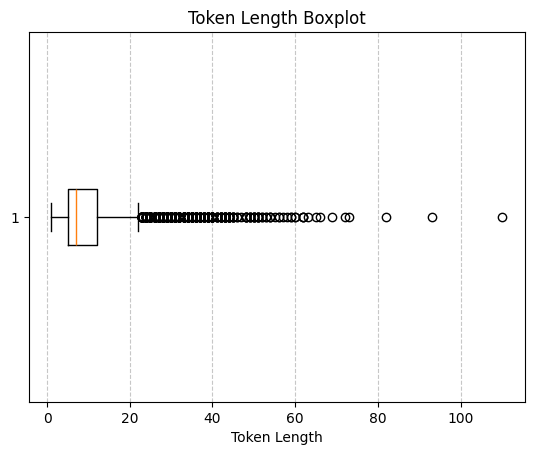

In [18]:
# Vẽ boxplot độ dài câu.
plt.boxplot(processed_token_len, vert=False)
plt.xlabel('Token Length')
plt.title('Token Length Boxplot')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [28]:
# 1. Build vocab
train_processed = [preprocess_text(item['sentence']) for item in train_raw]
all_tokens = []
for sent in train_processed:
    all_tokens.extend(sent.strip().split())
vocab_counter = Counter(all_tokens)
vocab = ['<pad>', '<unk>'] + [tok for tok, count in vocab_counter.items() if count >= 1]
word2idx = {word: idx for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

# 2. Encode
def encode_sentence(sentence, word2idx, max_len):
    tokens = sentence.strip().split()
    idxs = [word2idx.get(token, word2idx['<unk>']) for token in tokens]
    if len(idxs) < max_len:
        idxs += [word2idx['<pad>']] * (max_len - len(idxs))
    else:
        idxs = idxs[:max_len]
    return idxs

# 3. Labels
labels = ['positive', 'negative', 'neutral']
label2idx = {label: idx for idx, label in enumerate(labels)}

# 4. Process data
max_sequence = 40

def get_processed_and_labels(data_raw):
    processed = [preprocess_text(item['sentence']) for item in data_raw]
    # Encode sentence
    encoded = [encode_sentence(sent, word2idx, max_sequence) for sent in processed]
    # Encode label
    labels_idx = [label2idx[item['sentiment']] for item in data_raw]
    return encoded, labels_idx

In [29]:
print(vocab[:10])

['<pad>', '<unk>', 'slide', 'giáo_trình', 'đầy_đủ', 'nhiệt_tình', 'giảng_dạy', 'gần_gũi', 'với', 'sinh_viên']


In [30]:
example = "giáo trình hay"
encode_sentence(example, word2idx, max_sequence)

[1,
 986,
 27,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [40]:
# Tạo bộ dữ liệu train/dev/test đã mã hóa
X_train, y_train = get_processed_and_labels(train_raw)
X_dev, y_dev     = get_processed_and_labels(dev_raw)
X_test, y_test   = get_processed_and_labels(test_raw)

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 128
train_dataset = TextDataset(X_train, y_train)
dev_dataset = TextDataset(X_dev, y_dev)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [41]:
# Định nghĩa LSTM 5 lớp
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        emb = self.embedding(x)
        output, (hn, cn) = self.lstm(emb)
        last_hidden = hn[-1]
        out = self.fc(last_hidden)
        return out


embed_dim = 128
hidden_dim = 256
num_layers = 5
num_classes = len(labels)
pad_idx = word2idx['<pad>']

model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 100

In [42]:
def train_model(model, train_loader, dev_loader, criterion, optimizer, device, num_epochs, train_dataset, 
                patience=10, delta=1e-6, save_path="best_model_bai1.pt"):
    train_losses = []
    val_f1s = []
    best_f1 = None
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        
        avg_loss = total_loss / len(train_dataset)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}")
        
        # Evaluation trên dev set
        f1_dev = evaluate_model(model, dev_loader, device)
        val_f1s.append(f1_dev)
        print(f"Validation F1 (macro): {f1_dev:.4f}")

        # Early stopping logic
        if best_f1 is None or f1_dev > best_f1 + delta:
            best_f1 = f1_dev
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved at epoch {epoch+1} with F1 {best_f1:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load the best model before returning
    model.load_state_dict(torch.load(save_path))
    return model, train_losses, val_f1s

def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds, all_true = [], []
    
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(list(preds))
            all_true.extend(list(yb.numpy()))
    
    f1_score_value = f1_score(all_true, all_preds, average="macro")
    return f1_score_value

def visualize(train_losses, val_f1s=None, xlabel='Epoch', ylabel='Value', title='Training Progress'):
    import matplotlib.pyplot as plt

    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    if val_f1s is not None:
        plt.plot(epochs, val_f1s, label='Validation F1', marker='x')
        plt.ylabel('Loss / F1')
    else:
        plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [43]:
model, train_losses1, val_f1s1 = train_model(
    model=model,
    train_loader=train_loader,
    dev_loader=dev_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs,
    train_dataset=train_dataset,
    save_path='best_model_bai1_lstm'
)

# Đánh giá trên test set
f1_test = evaluate_model(model, test_loader, device)
print(f"F1 score (macro) on test set: {f1_test:.4f}")

Epoch 1/100, Train Loss: 0.9012
Validation F1 (macro): 0.2247
Best model saved at epoch 1 with F1 0.2247
Epoch 2/100, Train Loss: 0.8339
Validation F1 (macro): 0.2247
No improvement. Patience counter: 1/10
Epoch 3/100, Train Loss: 0.8040
Validation F1 (macro): 0.5319
Best model saved at epoch 3 with F1 0.5319
Epoch 4/100, Train Loss: 0.4977
Validation F1 (macro): 0.5785
Best model saved at epoch 4 with F1 0.5785
Epoch 5/100, Train Loss: 0.4063
Validation F1 (macro): 0.5909
Best model saved at epoch 5 with F1 0.5909
Epoch 6/100, Train Loss: 0.3631
Validation F1 (macro): 0.5989
Best model saved at epoch 6 with F1 0.5989
Epoch 7/100, Train Loss: 0.3347
Validation F1 (macro): 0.6059
Best model saved at epoch 7 with F1 0.6059
Epoch 8/100, Train Loss: 0.3079
Validation F1 (macro): 0.6097
Best model saved at epoch 8 with F1 0.6097
Epoch 9/100, Train Loss: 0.2844
Validation F1 (macro): 0.6103
Best model saved at epoch 9 with F1 0.6103
Epoch 10/100, Train Loss: 0.2642
Validation F1 (macro): 0.6

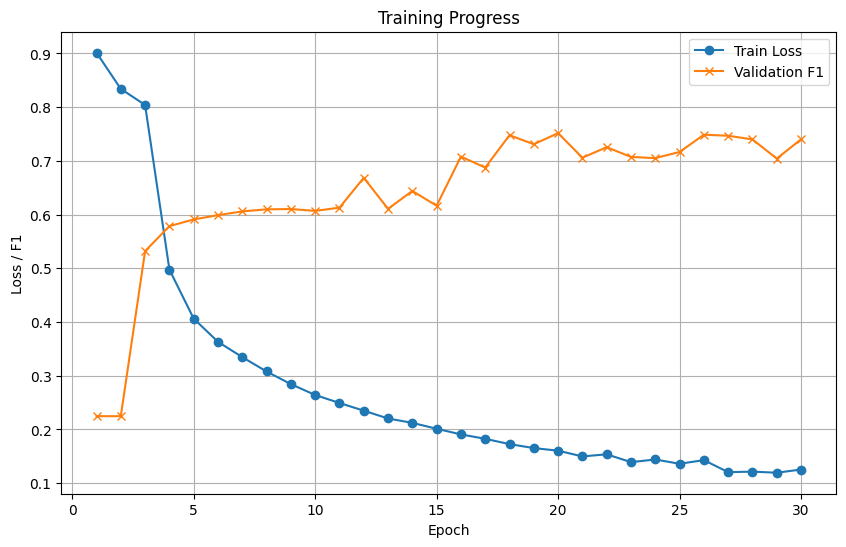

In [44]:
visualize(train_losses1, val_f1s=val_f1s1)

## Xây dựng mô hình

### Bài 2: Xây dựng mạng GRU gồm 5 lớp với hidden size là 256 cho bài toán phân loại văn bản. Huấn luyện mô hình này trên bộ dữ liệu UIT-VSFC (Vietnamese Student Feedback Corpus) sử dụng Adam làm phương thức tối ưu tham số và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

In [45]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        emb = self.embedding(x)
        output, hn = self.gru(emb)
        last_hidden = hn[-1]
        out = self.fc(last_hidden)
        return out


model2 = GRUClassifier(vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx).to(device)
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=1e-4)

In [46]:
model2, train_losses2, val_f1s2 = train_model(
    model=model2,
    train_loader=train_loader,
    dev_loader=dev_loader,
    criterion=criterion2,
    optimizer=optimizer2,
    device=device,
    num_epochs=num_epochs,
    train_dataset=train_dataset,
    save_path='best_model_bai2_gru'
)

# Đánh giá trên test set
f1_test2 = evaluate_model(model2, test_loader, device)
print(f"F1 score (macro) on test set: {f1_test2:.4f}")

Epoch 1/100, Train Loss: 0.8700
Validation F1 (macro): 0.2054
Best model saved at epoch 1 with F1 0.2054
Epoch 2/100, Train Loss: 0.8232
Validation F1 (macro): 0.4720
Best model saved at epoch 2 with F1 0.4720
Epoch 3/100, Train Loss: 0.4891
Validation F1 (macro): 0.5797
Best model saved at epoch 3 with F1 0.5797
Epoch 4/100, Train Loss: 0.3777
Validation F1 (macro): 0.5949
Best model saved at epoch 4 with F1 0.5949
Epoch 5/100, Train Loss: 0.3388
Validation F1 (macro): 0.6003
Best model saved at epoch 5 with F1 0.6003
Epoch 6/100, Train Loss: 0.3068
Validation F1 (macro): 0.6024
Best model saved at epoch 6 with F1 0.6024
Epoch 7/100, Train Loss: 0.2845
Validation F1 (macro): 0.6055
Best model saved at epoch 7 with F1 0.6055
Epoch 8/100, Train Loss: 0.2661
Validation F1 (macro): 0.6290
Best model saved at epoch 8 with F1 0.6290
Epoch 9/100, Train Loss: 0.2494
Validation F1 (macro): 0.6600
Best model saved at epoch 9 with F1 0.6600
Epoch 10/100, Train Loss: 0.2351
Validation F1 (macro):

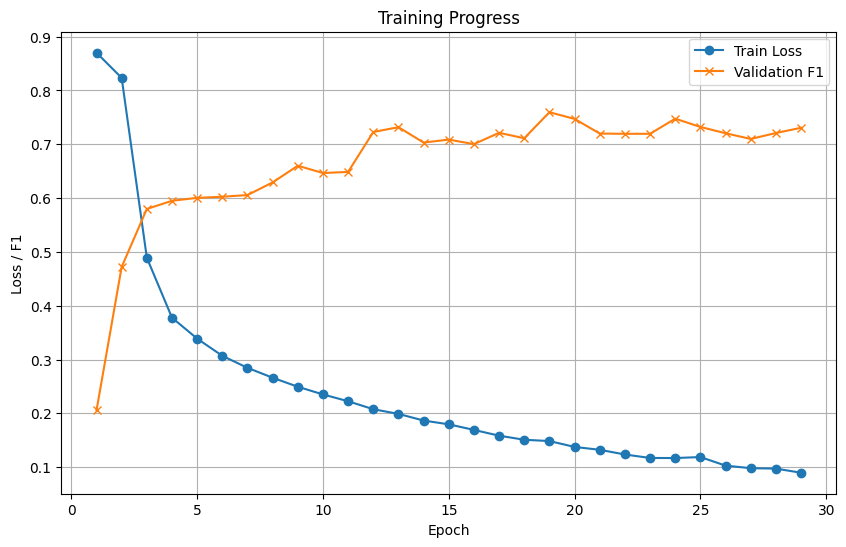

In [47]:
visualize(train_losses2, val_f1s=val_f1s2)

### Bài 3: Xây dựng kiến trúc Encoder trong đó Encoder gồm 5 lớp BiLSTM với hidden size là 256 cho bài toán nhận diện thực thể (Name Entity Recognition). Huấn luyện mô hình trên bộ dữ liệu PhoNER và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

## EDA PhoNER

### 1. Kiểm tra cấu trúc dữ liệu

In [48]:
# Tải và đọc các file train, test, dev.
!wget https://github.com/VinAIResearch/PhoNER_COVID19/archive/refs/heads/master.zip
!unzip master.zip

--2025-12-04 07:03:49--  https://github.com/VinAIResearch/PhoNER_COVID19/archive/refs/heads/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/VinAIResearch/PhoNER_COVID19/zip/main [following]
--2025-12-04 07:03:49--  https://codeload.github.com/VinAIResearch/PhoNER_COVID19/zip/main
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [       <=>          ]   3.60M  2.66MB/s    in 1.4s    

2025-12-04 07:03:51 (2.66 MB/s) - ‘master.zip’ saved [3777533]

Archive:  master.zip
9af190aa76adcfad0a2d14fab9bcab2b252c9c2e
   creating: PhoNER_COVID19-main/
  inflating: PhoNER_COVID19-main/

In [49]:
import json
import os

def load_jsonl(file_path):
    """Load JSONL format - mỗi dòng là một JSON object"""
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:  # Bỏ qua dòng trống
                try:
                    item = json.loads(line)
                    data.append(item)
                except json.JSONDecodeError as e:
                    print(f"Error parsing line: {line[:50]}...")
                    print(f"Error: {e}")
                    continue
    return data

# Sử dụng
data_dir = "./PhoNER_COVID19-main/data/word"
train_data = load_jsonl(os.path.join(data_dir, "train_word.json"))
test_data = load_jsonl(os.path.join(data_dir, "test_word.json"))
dev_data = load_jsonl(os.path.join(data_dir, "dev_word.json"))

print(f"Loaded {len(train_data)} training sentences")
print(f"Loaded {len(test_data)} test sentences")
print(f"Loaded {len(dev_data)} dev sentences")

Loaded 5027 training sentences
Loaded 3000 test sentences
Loaded 2000 dev sentences


In [50]:
# In 20 dòng đầu để xem cấu trúc dữ liệu BIO
train_data[20:]

[{'words': ['"',
   'Bệnh_nhân',
   '235',
   '"',
   ',',
   'nam',
   ',',
   '25',
   'tuổi',
   ',',
   'quốc_tịch',
   'Anh',
   ',',
   'ngày',
   '14/3',
   'đi',
   'quán',
   'bar',
   'Buddha',
   '.'],
  'tags': ['O',
   'O',
   'B-PATIENT_ID',
   'O',
   'O',
   'B-GENDER',
   'O',
   'B-AGE',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'B-DATE',
   'O',
   'B-LOCATION',
   'I-LOCATION',
   'I-LOCATION',
   'O']},
 {'words': ['Với',
   'việc',
   'có',
   'thêm',
   '8',
   'bệnh_nhân',
   'mới',
   '(',
   'từ',
   'bệnh_nhân',
   '374',
   'đến',
   '381',
   ')',
   ',',
   'Việt_Nam',
   'đã',
   'ghi_nhận',
   'tổng_số',
   '381',
   'ca',
   'bệnh',
   'trong',
   'mùa',
   'dịch',
   'này',
   ',',
   'trong',
   'đó',
   'có',
   '353',
   'người',
   'đã',
   'bình_phục',
   '(',
   'chiếm',
   'gần',
   '93%',
   ')',
   '.'],
  'tags': ['O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'B-PATIENT_ID',
   'O',
   'B-PATIENT_ID'

### 2. Thống kê số câu trong từng tập

In [51]:
# Số câu trong train/dev/test
print("Số câu trong tập train:", len(train_data))
print("Số câu trong tập test:", len(test_data))
print("Số câu trong tập dev:", len(dev_data))


Số câu trong tập train: 5027
Số câu trong tập test: 3000
Số câu trong tập dev: 2000


In [16]:
# Số lượng token mỗi tập
def count_tokens(data):
    return sum(len(item['words']) for item in data)

print("Số lượng token trong tập train:", count_tokens(train_data))
print("Số lượng token trong tập test:", count_tokens(test_data))
print("Số lượng token trong tập dev:", count_tokens(dev_data))

Số lượng token trong tập train: 132511
Số lượng token trong tập test: 85678
Số lượng token trong tập dev: 56283


### 3. Phân bố nhãn thực thể

In [52]:
# Thống kê số lần xuất hiện của từng nhãn (B-PER, I-PER, B-LOC, I-LOC, B-ORG, I-ORG, O,...).
def count_labels(data):
    label_counter = Counter()
    for item in data:
        label_counter.update(item['tags'])
    return label_counter

train_label_counts = count_labels(train_data)
test_label_counts = count_labels(test_data)
dev_label_counts = count_labels(dev_data)

print("Phân bố nhãn trong tập train:")
for label, count in train_label_counts.items():
    print(f"{label}: {count}")

print("\nPhân bố nhãn trong tập test:")
for label, count in test_label_counts.items():
    print(f"{label}: {count}")

print("\nPhân bố nhãn trong tập dev:")
for label, count in dev_label_counts.items():
    print(f"{label}: {count}")


Phân bố nhãn trong tập train:
O: 104750
B-ORGANIZATION: 1137
I-ORGANIZATION: 2545
B-SYMPTOM_AND_DISEASE: 1439
I-SYMPTOM_AND_DISEASE: 1552
B-LOCATION: 5398
B-DATE: 2549
B-PATIENT_ID: 3240
B-AGE: 682
B-NAME: 349
I-DATE: 2500
B-JOB: 205
I-LOCATION: 5242
B-TRANSPORTATION: 226
B-GENDER: 542
I-TRANSPORTATION: 67
I-JOB: 62
I-NAME: 13
I-AGE: 2
I-PATIENT_ID: 11

Phân bố nhãn trong tập test:
O: 63546
B-DATE: 1654
I-DATE: 1750
B-NAME: 318
B-AGE: 582
B-LOCATION: 4441
I-LOCATION: 4918
B-JOB: 173
I-JOB: 114
B-ORGANIZATION: 771
I-ORGANIZATION: 2014
B-PATIENT_ID: 2005
B-SYMPTOM_AND_DISEASE: 1136
I-SYMPTOM_AND_DISEASE: 1486
B-GENDER: 462
B-TRANSPORTATION: 193
I-TRANSPORTATION: 69
I-NAME: 13
I-PATIENT_ID: 27
I-AGE: 6

Phân bố nhãn trong tập dev:
O: 42166
B-ORGANIZATION: 551
I-ORGANIZATION: 1455
B-DATE: 1103
B-SYMPTOM_AND_DISEASE: 766
I-SYMPTOM_AND_DISEASE: 987
B-PATIENT_ID: 1276
B-GENDER: 277
B-AGE: 361
B-JOB: 132
I-JOB: 49
B-LOCATION: 2737
I-LOCATION: 2993
B-NAME: 188
I-DATE: 1118
B-TRANSPORTATION: 87


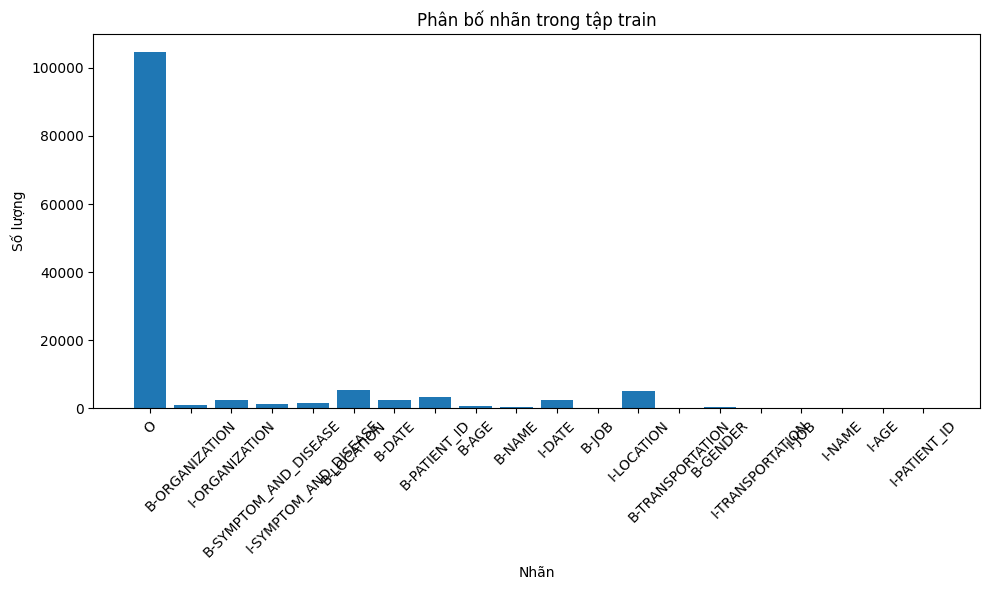

In [53]:
# Vẽ biểu đồ bar chart phân bố nhãn cho từng tập (train, test, dev)
def plot_label_distribution(label_counts, title):
    labels = list(label_counts.keys())
    counts = list(label_counts.values())

    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts)
    plt.title(title)
    plt.xlabel('Nhãn')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_label_distribution(train_label_counts, 'Phân bố nhãn trong tập train')
# plot_label_distribution(test_label_counts, 'Phân bố nhãn trong tập test')
# plot_label_distribution(dev_label_counts, 'Phân bố nhãn trong tập dev')

**Trả lời:**
* Nhãn `O` xuất hiện nhiều nhất
* Các nhãn hiếm (dưới 100 lần xuất hiện): I-TRANSPORTATION, I-JOB, I-NAME, I-AGE, I-PATIENT_ID

### 4. Phân tích độ dài câu

In [54]:
# Tính số token cho từng câu.
sentence_lengths = []
for sample in train_data:
    num_tokens = len(sample['words'])
    sentence_lengths.append(num_tokens)

print(sentence_lengths[:10])


[18, 48, 27, 27, 24, 59, 45, 19, 15, 14]


In [55]:
min_len = np.min(sentence_lengths)
max_len = np.max(sentence_lengths)
mean_len = np.mean(sentence_lengths)

print('Min sentence length:', min_len)
print('Max sentence length:', max_len)
print('Mean sentence length:', mean_len)


Min sentence length: 6
Max sentence length: 161
Mean sentence length: 26.359856773423513


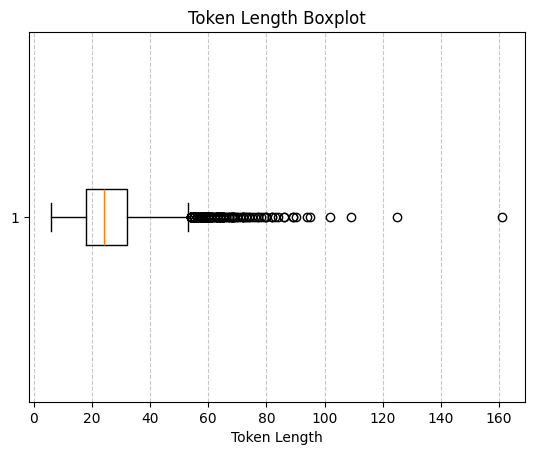

In [56]:
# Vẽ boxplot độ dài câu.
plt.boxplot(sentence_lengths, vert=False)
plt.xlabel('Token Length')
plt.title('Token Length Boxplot')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

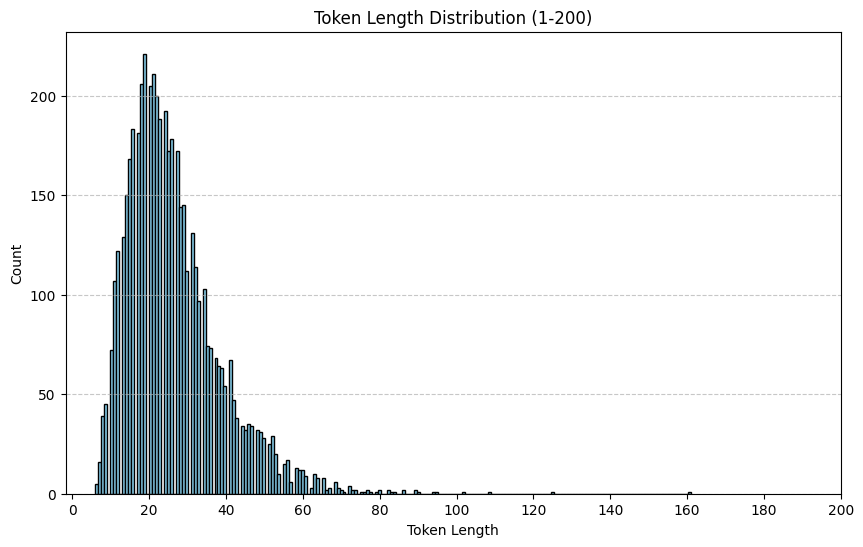

In [57]:
# Vẽ histogram độ dài câu.

plt.figure(figsize=(10,6))
plt.hist(sentence_lengths, bins=200, color='skyblue', edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Count')
plt.title('Token Length Distribution (1-200)')
plt.xticks(range(0, 201, 20))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Trả lời câu hỏi:**
* Phần lớn câu nằm trong khoảng 10-40 tokens, nhưng để bao phủ hầu hết thì nên chọn 60-80 tokens và lựa chọn an toàn là `70 tokens` trade-off cho chi phí tính toán, thời gian,...
* Các câu dài **>80 tokens** sẽ ảnh hưởng đến LSTM -> dễ bị `vanishing gradient` đồng thời gây ra `lãng phí tài nguyên ` nếu giữ các câu này.

### Xây dựng mô hình

In [64]:
# 1. Build vocab từ train_data (tương tự Bài 1)

# Lấy tokens từ train_data (có thể là 'words' hoặc 'tokens')
all_tokens_ner = []
for item in train_data:
    tokens = item.get('words', item.get('tokens', []))
    all_tokens_ner.extend(tokens)

vocab_counter_ner = Counter(all_tokens_ner)
vocab_ner = ['<pad>', '<unk>'] + [tok for tok, count in vocab_counter_ner.items() if count >= 1]
word2idx_ner = {word: idx for idx, word in enumerate(vocab_ner)}
vocab_size_ner = len(word2idx_ner)

In [65]:
# 2. Build label vocab từ train_data

all_labels_ner = []
for item in train_data:
    labels = item.get('tags', item.get('ner_tags', []))
    all_labels_ner.extend(labels)

label_set_ner = sorted(list(set(all_labels_ner)))
label_vocab_ner = ['<pad>'] + label_set_ner
label2idx_ner = {label: idx for idx, label in enumerate(label_vocab_ner)}
idx2label_ner = {idx: label for label, idx in label2idx_ner.items()}
num_labels_ner = len(label2idx_ner)

pad_token_idx_ner = word2idx_ner['<pad>']
pad_label_idx_ner = label2idx_ner['<pad>']

print(f"Number of labels: {num_labels_ner}")
print(f"Labels: {label_vocab_ner[:10]}...")  # In 10 labels đầu

# Phân tích độ dài câu để chọn max_len
sentence_lengths_ner = [len(item.get('words', item.get('tokens', []))) for item in train_data]
print(f"Min/Max/Mean sentence length: {np.min(sentence_lengths_ner)}, {np.max(sentence_lengths_ner)}, {np.mean(sentence_lengths_ner):.2f}")

# Chọn max_len = 80 (dựa trên phân tích từ histogram)
max_len_ner = 70
print(f"Using max_len for NER: {max_len_ner}")

Number of labels: 21
Labels: ['<pad>', 'B-AGE', 'B-DATE', 'B-GENDER', 'B-JOB', 'B-LOCATION', 'B-NAME', 'B-ORGANIZATION', 'B-PATIENT_ID', 'B-SYMPTOM_AND_DISEASE']...
Min/Max/Mean sentence length: 6, 161, 26.36
Using max_len for NER: 70


In [66]:
# 3. Hàm encode câu NER (tương tự encode_sentence trong Bài 1)

def encode_ner_sentence(tokens, labels, word2idx, label2idx, max_len):
    """Encode tokens và labels thành indices, đảm bảo cùng độ dài"""
    # Xử lý trường hợp rỗng
    if not tokens or not labels:
        # Trả về toàn pad nếu rỗng
        return [word2idx['<pad>']] * max_len, [label2idx['<pad>']] * max_len
    
    # Đảm bảo tokens và labels cùng độ dài (lấy min_len)
    min_len = min(len(tokens), len(labels))
    tokens = tokens[:min_len]
    labels = labels[:min_len]
    
    token_ids = [word2idx.get(token, word2idx['<unk>']) for token in tokens]
    label_ids = [label2idx.get(label, label2idx['<pad>']) for label in labels]
    
    # Pad hoặc truncate về max_len
    if len(token_ids) < max_len:
        # Padding
        pad_len = max_len - len(token_ids)
        token_ids += [word2idx['<pad>']] * pad_len
        label_ids += [label2idx['<pad>']] * pad_len
    else:
        # Truncate
        token_ids = token_ids[:max_len]
        label_ids = label_ids[:max_len]
    
    # Đảm bảo kết quả có đúng max_len
    assert len(token_ids) == max_len, f"Token length mismatch: {len(token_ids)} != {max_len}"
    assert len(label_ids) == max_len, f"Label length mismatch: {len(label_ids)} != {max_len}"
    
    return token_ids, label_ids

In [67]:
# 4. Process data (tương tự get_processed_and_labels trong Bài 1)

def get_processed_ner_data(data_raw, word2idx, label2idx, max_len):
    """Process NER data, tương tự get_processed_and_labels trong Bài 1"""
    encoded = []
    labels_encoded = []
    skipped = 0
    
    for item in data_raw:
        tokens = item.get('words', item.get('tokens', []))
        labels = item.get('labels', item.get('ner_tags', item.get('tags', [])))
        
        # Bỏ qua nếu không có tokens hoặc labels
        if not tokens or not labels:
            skipped += 1
            continue
        
        token_ids, label_ids = encode_ner_sentence(tokens, labels, word2idx, label2idx, max_len)
        
        # Đảm bảo kết quả có đúng độ dài
        assert len(token_ids) == max_len, f"Token length {len(token_ids)} != {max_len}"
        assert len(label_ids) == max_len, f"Label length {len(label_ids)} != {max_len}"
        
        encoded.append(token_ids)
        labels_encoded.append(label_ids)
    
    if skipped > 0:
        print(f"⚠️ Skipped {skipped} items without tokens/labels")
    
    return encoded, labels_encoded

X_train_ner, y_train_ner = get_processed_ner_data(train_data, word2idx_ner, label2idx_ner, max_len_ner)
X_dev_ner,   y_dev_ner   = get_processed_ner_data(dev_data,   word2idx_ner, label2idx_ner, max_len_ner)
X_test_ner,  y_test_ner  = get_processed_ner_data(test_data,  word2idx_ner, label2idx_ner, max_len_ner)

print(f"Encoded NER shapes:")
print(f"  Train: {len(X_train_ner)}, {len(X_train_ner[0])}")
print(f"  Dev:   {len(X_dev_ner)},   {len(X_dev_ner[0])}")
print(f"  Test:  {len(X_test_ner)},  {len(X_test_ner[0])}")

Encoded NER shapes:
  Train: 5027, 70
  Dev:   2000,   70
  Test:  3000,  70


In [68]:
# 5. Dataset & DataLoader

class NERDataset(Dataset):
    def __init__(self, X, y, max_len=None):
        # Đảm bảo tất cả có cùng độ dài trước khi tạo tensor
        if max_len is None:
            max_len = max(len(x) for x in X) if X else 0
        
        # Fix độ dài cho tất cả các câu
        fixed_X, fixed_y = [], []
        pad_token = word2idx_ner['<pad>']
        pad_label = label2idx_ner['<pad>']
        
        for x, y_item in zip(X, y):
            if len(x) != max_len:
                if len(x) < max_len:
                    x = x + [pad_token] * (max_len - len(x))
                    y_item = y_item + [pad_label] * (max_len - len(y_item))
                else:
                    x = x[:max_len]
                    y_item = y_item[:max_len]
            fixed_X.append(x)
            fixed_y.append(y_item)
        
        # Kiểm tra lại trước khi tạo tensor
        assert all(len(x) == max_len for x in fixed_X), f"Not all sequences have same length! Found lengths: {set(len(x) for x in fixed_X)}"
        assert all(len(y) == max_len for y in fixed_y), f"Not all labels have same length! Found lengths: {set(len(y) for y in fixed_y)}"
        
        self.X = torch.tensor(fixed_X, dtype=torch.long)
        self.y = torch.tensor(fixed_y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size_ner = 32
train_ner_dataset = NERDataset(X_train_ner, y_train_ner, max_len=max_len_ner)
dev_ner_dataset   = NERDataset(X_dev_ner,   y_dev_ner,   max_len=max_len_ner)
test_ner_dataset  = NERDataset(X_test_ner,  y_test_ner,  max_len=max_len_ner)

train_ner_loader = DataLoader(train_ner_dataset, batch_size=batch_size_ner, shuffle=True)
dev_ner_loader   = DataLoader(dev_ner_dataset,   batch_size=batch_size_ner)
test_ner_loader  = DataLoader(test_ner_dataset,  batch_size=batch_size_ner)

In [69]:
# 6. Định nghĩa Encoder BiLSTM 5 lớp

class BiLSTMNEREncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_labels, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.bilstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        emb = self.embedding(x)                  # (B, T, E)
        lstm_out, _ = self.bilstm(emb)          # (B, T, 2H)
        logits = self.fc(lstm_out)              # (B, T, num_labels)
        return logits


embed_dim_ner = 128
hidden_dim_ner = 256
num_layers_ner = 5

model_ner = BiLSTMNEREncoder(
    vocab_size=vocab_size_ner,
    embed_dim=embed_dim_ner,
    hidden_dim=hidden_dim_ner,
    num_layers=num_layers_ner,
    num_labels=num_labels_ner,
    pad_idx=pad_token_idx_ner,
).to(device)

criterion_ner = nn.CrossEntropyLoss(ignore_index=pad_label_idx_ner)
optimizer_ner = optim.Adam(model_ner.parameters(), lr=1e-3)

print("NER model parameters:", sum(p.numel() for p in model_ner.parameters()))

NER model parameters: 7780245


In [70]:
# 7. Hàm evaluate F1 cho NER (token-level, macro F1, bỏ qua pad)

def evaluate_ner(model, data_loader, device, pad_label_idx):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)                  # (B, T, C)
            preds = torch.argmax(logits, dim=-1)  # (B, T)
            # Flatten và bỏ pad
            preds_flat = preds.view(-1).cpu().numpy()
            labels_flat = yb.view(-1).cpu().numpy()
            mask = labels_flat != pad_label_idx
            preds_flat = preds_flat[mask]
            labels_flat = labels_flat[mask]
            all_preds.extend(preds_flat.tolist())
            all_true.extend(labels_flat.tolist())
    f1 = f1_score(all_true, all_preds, average="macro", zero_division=0)
    return f1


# 8. Hàm train với early stopping (tái sử dụng ý tưởng từ bài 1)

def train_ner_model(model, train_loader, dev_loader, criterion, optimizer, device,
                    num_epochs=30, patience=5, delta=1e-4, pad_label_idx=0,
                    save_path="best_ner_model.pt"):
    best_f1 = None
    patience_counter = 0
    train_losses = []
    val_f1s = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion_ner(logits.view(-1, num_labels_ner), yb.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        f1_dev = evaluate_ner(model, dev_loader, device, pad_label_idx)
        val_f1s.append(f1_dev)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val F1: {f1_dev:.4f}")

        # Early stopping
        if best_f1 is None or f1_dev > best_f1 + delta:
            best_f1 = f1_dev
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"Best model saved at epoch {epoch+1} with F1 {best_f1:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))
    return model, train_losses, val_f1s

In [71]:
# 9. Huấn luyện và đánh giá trên PhoNER

num_epochs_ner = 30

model_ner, train_losses_ner, val_f1s_ner = train_ner_model(
    model_ner,
    train_ner_loader,
    dev_ner_loader,
    criterion_ner,
    optimizer_ner,
    device,
    num_epochs=num_epochs_ner,
    patience=7,
    delta=1e-4,
    pad_label_idx=pad_label_idx_ner,
    save_path="best_ner_bilstm.pt",
)

f1_test_ner = evaluate_ner(model_ner, test_ner_loader, device, pad_label_idx_ner)
print(f"F1 score (macro) on PhoNER test set: {f1_test_ner:.4f}")

Epoch 1/30, Train Loss: 0.9423, Val F1: 0.2305
Best model saved at epoch 1 with F1 0.2305
Epoch 2/30, Train Loss: 0.2541, Val F1: 0.5361
Best model saved at epoch 2 with F1 0.5361
Epoch 3/30, Train Loss: 0.1220, Val F1: 0.5590
Best model saved at epoch 3 with F1 0.5590
Epoch 4/30, Train Loss: 0.0892, Val F1: 0.6476
Best model saved at epoch 4 with F1 0.6476
Epoch 5/30, Train Loss: 0.0606, Val F1: 0.6776
Best model saved at epoch 5 with F1 0.6776
Epoch 6/30, Train Loss: 0.0446, Val F1: 0.6880
Best model saved at epoch 6 with F1 0.6880
Epoch 7/30, Train Loss: 0.0549, Val F1: 0.7201
Best model saved at epoch 7 with F1 0.7201
Epoch 8/30, Train Loss: 0.0279, Val F1: 0.7309
Best model saved at epoch 8 with F1 0.7309
Epoch 9/30, Train Loss: 0.0221, Val F1: 0.7846
Best model saved at epoch 9 with F1 0.7846
Epoch 10/30, Train Loss: 0.0204, Val F1: 0.7438
No improvement. Patience counter: 1/7
Epoch 11/30, Train Loss: 0.0166, Val F1: 0.7515
No improvement. Patience counter: 2/7
Epoch 12/30, Train

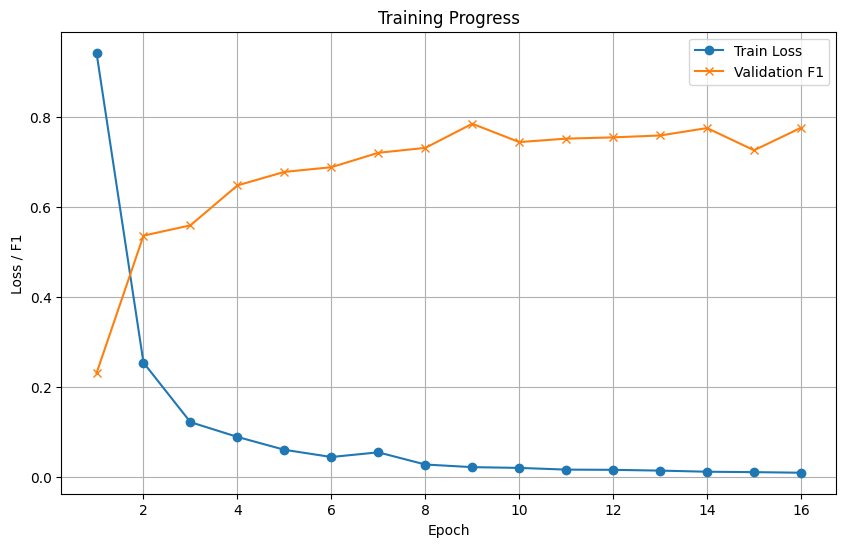

In [72]:
visualize(train_losses_ner, val_f1s_ner)